In [ ]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print, fig_loops
from utils.pd_utils import sort_cycle, get_life_times
from utils.passing_cells_utils import fig_distribution, fig_loops_curve

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd

from vis_utils.rnaseqTools import geneSelection, sparseload
import pickle
import torch
import urllib.request
import requests
 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


In [837]:
root_path = get_path("data")
fig_path = os.path.join(root_path, "figures")
seeds = [0]
k = 15

style_file = "utils.style"
plt.style.use(style_file)

In [840]:
distances_1 = {
    "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

In [841]:
distances_2 = {
    "euclidean": [{}],
    "diffusion": [
        {"k": 15, "t": 8, "kernel": "sknn", "include_self": False, "sparse_array": True},
        {"k": 100, "t": 8, "kernel": "sknn", "include_self": False, "sparse_array": True},
        {"k": 15, "t": 64, "kernel": "sknn", "include_self": False, "sparse_array": True},
        {"k": 100, "t": 64, "kernel": "sknn", "include_self": False, "sparse_array": True},
    ],
    "eff_res": [
        {"corrected": True, "weighted": False, "k": 15, "disconnect": True},
        {"corrected": True, "weighted": False, "k": 100, "disconnect": True},
    ],
}

In [842]:
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
# seed = 0
file_name = os.path.join(root_path,
                         "yao_10x_male",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_0_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd = tsne_data["embds"][-1]

# mask making

In [843]:
_, _, _, _, full_d = load_dataset(root_path, "yao_10x_male", k=k)

In [844]:
idx_orange = [i for i, cluster in enumerate(full_d["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
cluster_orange = [cluster for i, cluster in enumerate(full_d["clusterNames"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]


In [845]:

mask_orange = [idx in idx_orange for idx in full_d['clusters']]
idx_mask_orange = [i for i, idx in enumerate(full_d['clusters']) if idx in idx_orange]
np.random.seed(0)
mm_o = np.random.choice(len(idx_mask_orange), 20000, replace=False)


# distance sample then ph

In [ ]:
x, y, sknn, pca2, d = load_dataset(root_path, "yao_10x_male_orange", k=15, seed=0)
all_res_sample = load_multiple_res(datasets="yao_10x_male_orange_0_10k", n=None, embd_dims=None, sigmas=None, distances=distances_1, seeds=0, root_path=root_path, n_threads=1)
all_res_anosample = load_multiple_res(datasets="yao_10x_male_orange", n=None, embd_dims=None, sigmas=None, distances=distances_2, seeds=0, root_path=root_path, n_threads=1)
new_all_res_sample = {key: value for distance in all_res_sample.values() for key, value in distance.items()}
new_all_res_anosample = {key: value for distance in all_res_anosample.values() for key, value in distance.items()}


Done with yao_10x_male_orange_0_10k None euclidean n_outliers=0, perturbation=None
Done with yao_10x_male_orange_0_10k None diffusion_k_15_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_0_10k None diffusion_k_100_t_8_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_0_10k None diffusion_k_15_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_0_10k None diffusion_k_100_t_64_kernel_sknn_include_self_False n_outliers=0, perturbation=None
Done with yao_10x_male_orange_0_10k None eff_res_corrected_True_weighted_False_k_15_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_orange_0_10k None eff_res_corrected_True_weighted_False_k_100_disconnect_True n_outliers=0, perturbation=None
Done with yao_10x_male_orange None euclidean n_outliers=0, perturbation=None
Done with yao_10x_male_orange None diffusion_k_15_t_8_kernel_sknn_include_self_

In [864]:
new_all_res = {}
for all_keys in list(all_res_sample.keys()):
    for sub_key1, sub_key2 in zip(list(all_res_sample[all_keys].keys()),  list(all_res_anosample[all_keys].keys())):
        new_all_res[all_keys] = {
            f"{sub_key1}, sample before calculating distance": all_res_sample[all_keys][sub_key1], 
            f"{sub_key1}, sample after calculating distance": all_res_anosample[all_keys][sub_key2]
        }

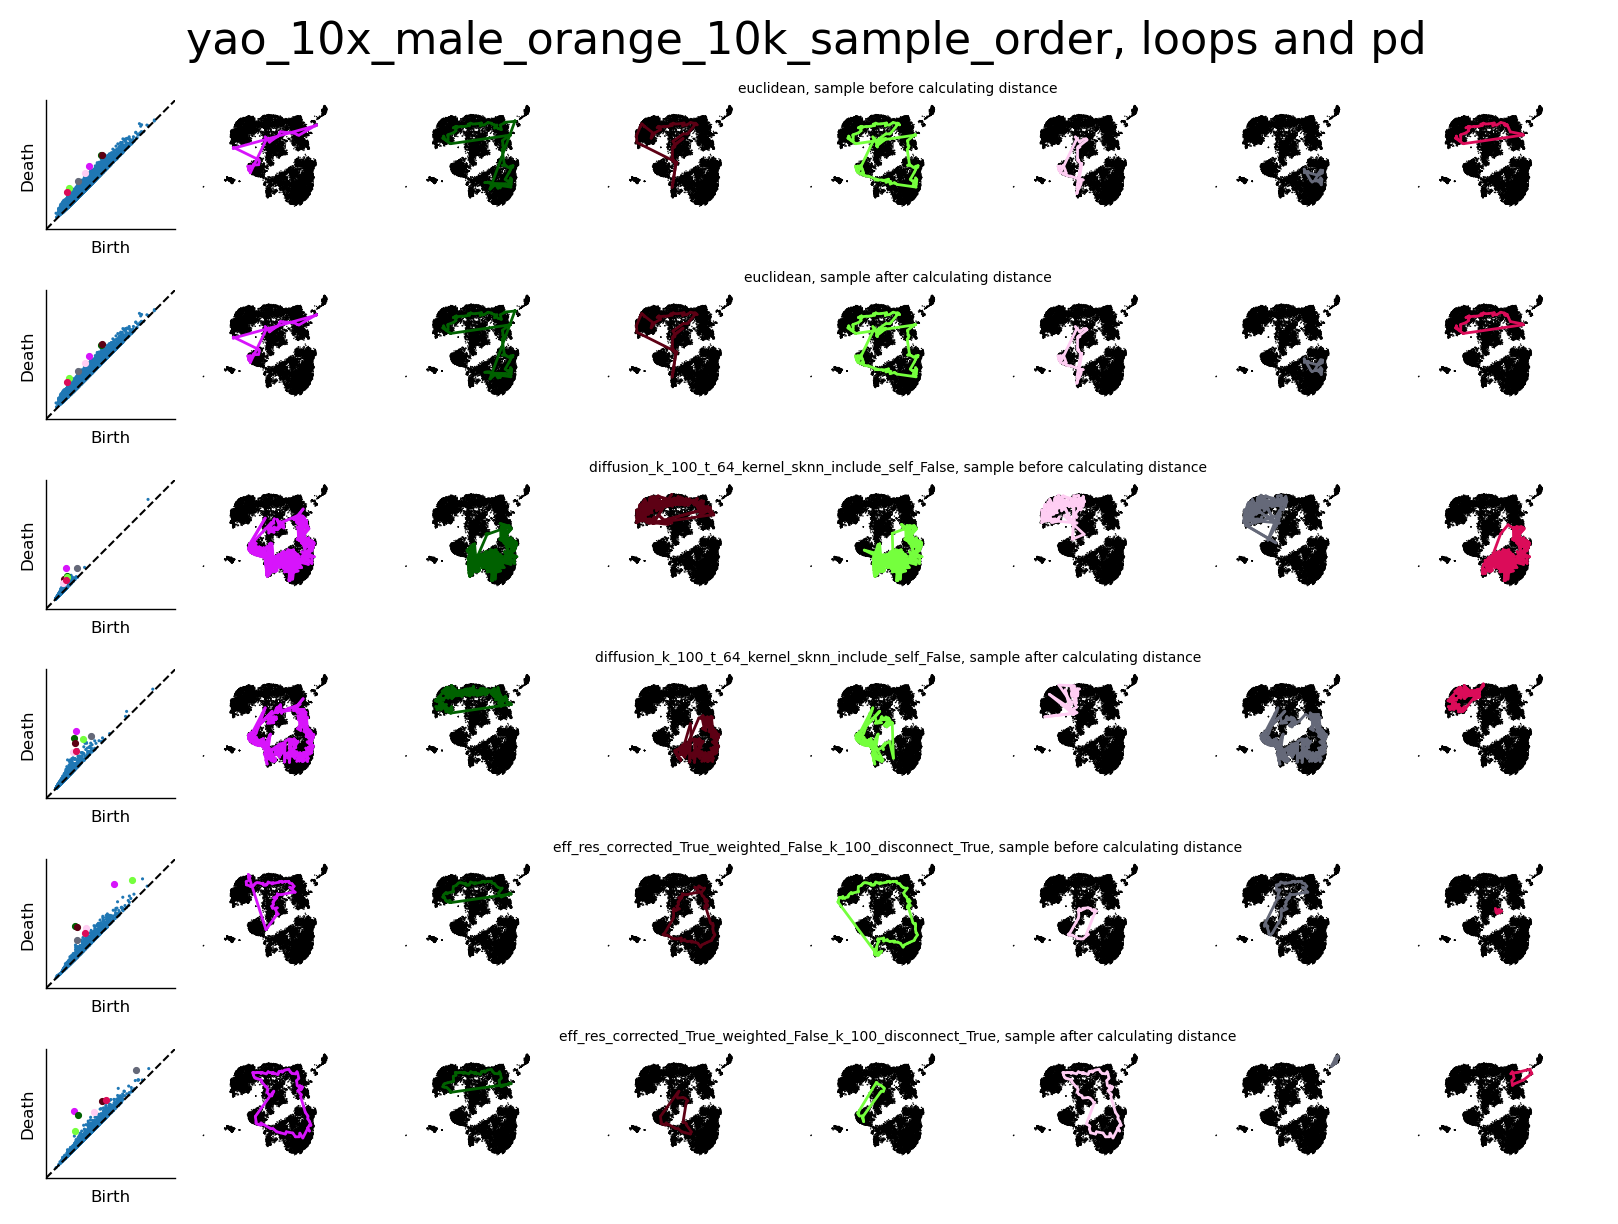

In [863]:
fig_loops(new_all_res, embd_n_mask = embd[mask_orange][mm_o], cell_group_name = "yao_10x_male_orange_10k_sample_order", save = False)